# Rolling Walk-Forward Approach

As discussed in [notebook 2](02_baseline_cointegration.ipynb), the absence of full-history cointegration is consistent with the relationship being unstable across regimes. To check for localised short-term relationships we may employ a rolling approach. This means we test for cointegration in lookback windows of $n$ days in a rolling manner. We may use a smaller step size $s$ than our lookback window size $n$. This will give us overlapping windows to ensure that a regime that starts or ends somewhere in the middle of one of our blocks doesn't go undetected. However, it is important to note that a smaller $s$ increases the overlap between consecutive windows, so results across neighbouring windows should not be read as independent.

If we find any periods of cointegration, we can then fit a regression model and walk forward $m$ days to test whether the relationship holds. Note that testing whether the fitted model has stationary residuals here does not suffer from the same bias issue as if we were testing it on the data it had been fitted on, so we may employ an ADF test rather than an EG test here.

We treat these as two separate questions: whether short-term cointegrating relationships occur at all (the rolling lookback search), and whether relationships identified this way continue to hold out-of-sample (addressed separately via walk-forward analysis once candidate windows have been identified).


In [34]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import coint

from helpers.plots import model_fit_and_plots


In [35]:
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/pep_ko_daily.csv", index_col=0)

## Rolling Lookback Window Length and Step Size 

The length of the rolling window and step size ($n$ and $s$ respectively) are parameters to be experimented with. 

We will start with $n=100$ (roughly 20 weeks, dependent on holidays) and $s=25$. Admittedly, this is a rather arbitrary starting choice aimed at giving ourselves enough data to fit the model whilst minimising our exposure to the same regime-breaking issues as [notebook 2](02_baseline_cointegration.ipynb) and also maximising our chances of finding regimes.

With this in mind, it is important that we properly correct our $10\%$ significance threshold to account for the number of tests we will be running. We will do this using a simple Bonferroni correction. However, note that since we are conducting many tests that are not independent, not least due to the overlapping windows, this will be a conservative adjustment. Having said this, we will be doing two tests in each block corresponding to the two directions, and will require both tests to pass in order to conclude that the pair is cointegrated, but this does not need to be factored in to our correction, per Berger in his [1982 paper](https://doi.org/10.1080/00401706.1982.10487774). 

In [3]:
n_1 = 100
s_1 = 25
alpha = 0.1

num_tests = int(1 + np.floor((len(df) - n_1) / s_1))
sig_level_adj_coin = alpha / num_tests

print("Number of individual tests ran at this stage: ", num_tests)
print("Adjusted per-test significance level for cointegration identification: ", sig_level_adj_coin)

Number of individual tests ran at this stage:  544
Adjusted per-test significance level for cointegration identification:  0.0001838235294117647


## Cointegration Identification

We can now perform out rolling lookback search to identify periods of cointegration.

In [4]:
df.sort_index(inplace=True)
df_log = df[[]].copy()
df_log['log_close_pep'] = np.log(df['close_pep'])
df_log['log_close_ko'] = np.log(df['close_ko'])

In [5]:
def rolling_lookback_cointegration(data, col1, col2, n_lookback, step_size, sig_level):
    num_tests = int(1 + np.floor((len(data) - n_lookback) / step_size))
    sig_level_adj_coin = sig_level / num_tests


    identified_relationships = {"lookback_date": [], "pvalue_block_1_2": [], "pvalue_block_2_1": []}

    for i in range(num_tests):
        block_start = i * step_size
        block_end = block_start + n_lookback
        lookback_date = data.index[block_end]

        df_block = data[block_start: block_end] 

        _, pvalue_block_1_2, _ = coint(df_block[col1], df_block[col2])
        _, pvalue_block_2_1, _ = coint(df_block[col2], df_block[col1])

        if (pvalue_block_2_1 < sig_level_adj_coin) and (pvalue_block_1_2 < sig_level_adj_coin):

            identified_relationships["lookback_date"].append(lookback_date)
            identified_relationships["pvalue_block_1_2"].append(pvalue_block_1_2)
            identified_relationships["pvalue_block_2_1"].append(pvalue_block_2_1)

        if i % 100 == 0:
            print(i, " of ", num_tests, " completed")

    print("done!")

    return pd.DataFrame(identified_relationships)

In [6]:
identified_relationships_1 = rolling_lookback_cointegration(df_log, 'log_close_pep', 'log_close_ko', n_1, s_1, alpha)

0  of  544  completed
100  of  544  completed
200  of  544  completed
300  of  544  completed
400  of  544  completed
500  of  544  completed
done!


In [7]:
identified_relationships_1

,lookback_date,pvalue_block_1_2,pvalue_block_2_1
0,1978-07-25,0.000118,1.437659e-04
1,1987-12-15,0.000001,4.960707e-07


In [8]:
df_coin_1 = df_log[:identified_relationships_1['lookback_date'][0]].tail(n_1)
df_coin_2 = df_log[:identified_relationships_1['lookback_date'][1]].tail(n_1)

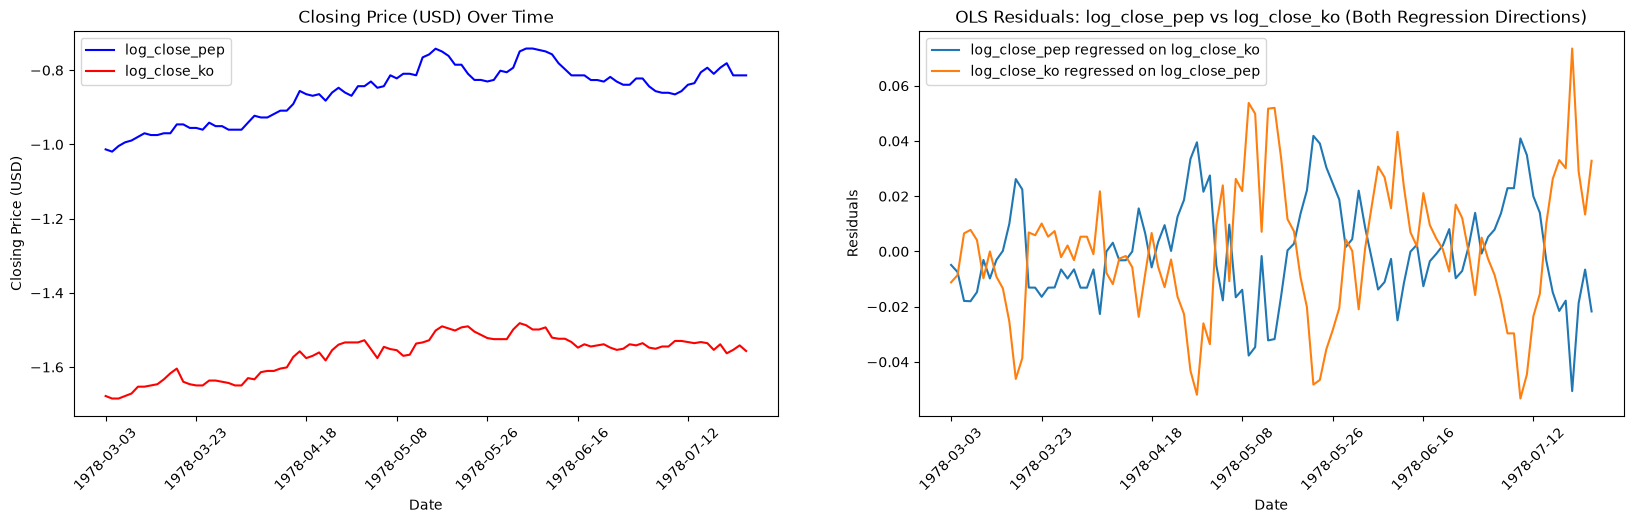

In [9]:
results_1_dict = model_fit_and_plots(df_coin_1, 'log_close_pep', 'log_close_ko', "Closing Price (USD)")

In [10]:
print("Fitting Models on ", n_1, " days leading up to ", identified_relationships_1['lookback_date'][0])
print(" PEP regressed on KO: Beta = ", results_1_dict['log_close_pep on log_close_ko'].params['log_close_pep'])
print(" KO regressed on PEP: Beta = ", results_1_dict['log_close_ko on log_close_pep'].params['log_close_ko'])

Fitting Models on  100  days leading up to  1978-07-25
 PEP regressed on KO: Beta =  0.6924392965828299
 KO regressed on PEP: Beta =  1.2819325534170574


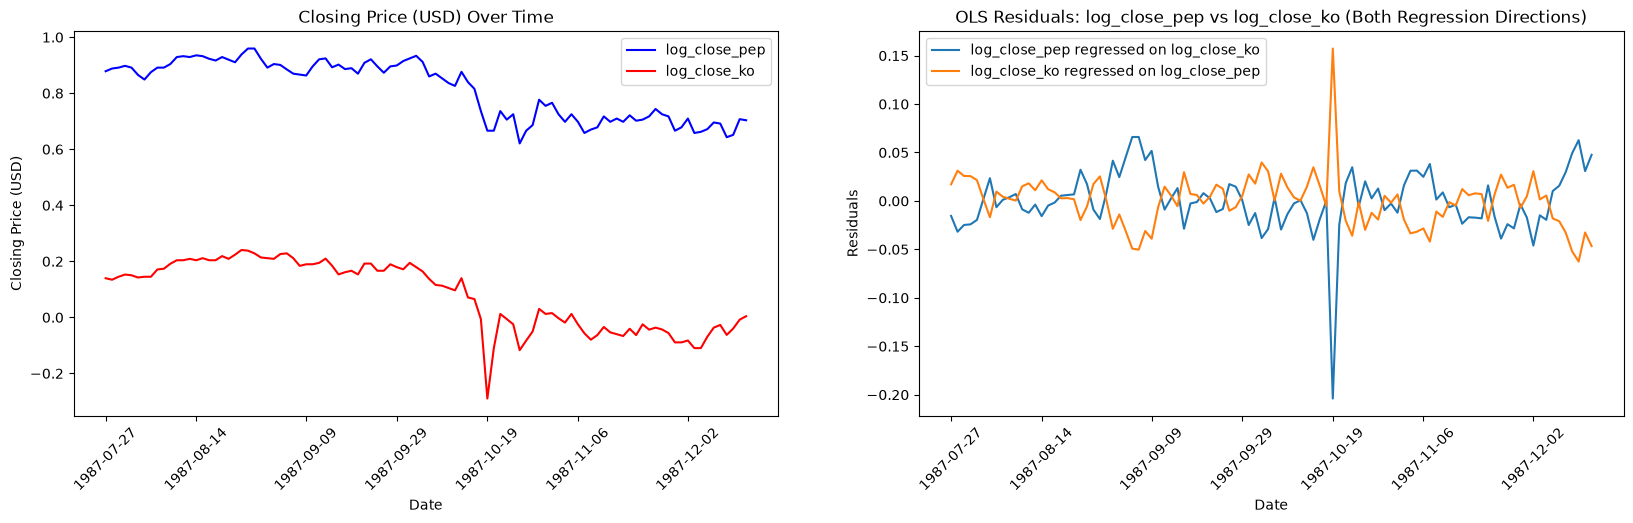

In [11]:
results_2_dict = model_fit_and_plots(df_coin_2, 'log_close_pep', 'log_close_ko', "Closing Price (USD)")

In [12]:
print("Fitting Models on ", n_1, " days leading up to ", identified_relationships_1['lookback_date'][1])
print(" PEP regressed on KO: Beta = ", results_2_dict['log_close_pep on log_close_ko'].params['log_close_pep'])
print(" KO regressed on PEP: Beta = ", results_2_dict['log_close_ko on log_close_pep'].params['log_close_ko'])

Fitting Models on  100  days leading up to  1987-12-15
 PEP regressed on KO: Beta =  1.1346997358071897
 KO regressed on PEP: Beta =  0.8208082805573877


## Walk-Forward Analysis

Now that we have identified two periods of 100 days where PEP and KO are cointegrated, we can analyse for how long, if at all, the trend holds. We will do this by evaluating our fitted models on the following $m$ days worth of data after our cointegration periods and testing the residuals for stationarity. As mentioned above, we may use the ADF test here because the same bias does not apply as if we were to use this test on the same data the model was fitted on. In the same way as before, we will test both directions and require that both pass to conclude a relationship.

In practice, we will test a few different values for $m$ here and correct our significance threshold accordingly.

In [13]:
m_list_1 = [5, 10, 20, 50]

In [24]:
for idx, relationship in identified_relationships_1.iterrows():
    print(relationship["lookback_date"])


1978-07-25
1987-12-15


In [22]:
identified_relationships_1

,lookback_date,pvalue_block_1_2,pvalue_block_2_1
0,1978-07-25,0.000118,1.437659e-04
1,1987-12-15,0.000001,4.960707e-07


In [65]:
def walkforward_analysis(data, col1, col2, identified_relationships, n_lookback, m_list, alpha, plot_if_sig):
    num_tests = len(identified_relationships) * len(m_list)
    sig_level_adj_wf = alpha / num_tests

    persisting_relationships = {"lookback_date": [], "m": []}

    for _, relationship in identified_relationships.iterrows():
        lookback_date = relationship['lookback_date']

        train = data[data.index < lookback_date].tail(n_lookback)

        model_1_2 = sm.OLS(train[col2], sm.add_constant(train[col1]))
        results_1_2 = model_1_2.fit()

        model_2_1 = sm.OLS(train[col1], sm.add_constant(train[col2]))
        results_2_1 = model_2_1.fit()

        for m in m_list:
            df_wf = data[data.index >= lookback_date].copy().head(m)

            df_wf['col2_resid'] = df_wf[col2] - results_1_2.predict(sm.add_constant(df_wf[col1]))
            df_wf['col1_resid'] = df_wf[col1] - results_2_1.predict(sm.add_constant(df_wf[col2]))


            pvalue_wf_1_2 = adfuller(df_wf['col2_resid'])[1]
            pvalue_wf_2_1 = adfuller(df_wf['col1_resid'])[1]

            if (pvalue_wf_1_2 < sig_level_adj_wf) and (pvalue_wf_2_1 < sig_level_adj_wf):
                persisting_relationships["lookback_date"].append(lookback_date)
                persisting_relationships["m"].append(m)          

                if plot_if_sig:
                    df_wf['col2_resid'].plot()
                    df_wf['col1_resid'].plot()
                    plt.show()


    return(persisting_relationships)
            

In [66]:
walkforward_analysis(df_log, 'log_close_pep', 'log_close_ko', identified_relationships_1, n_1, m_list_1, alpha, plot_if_sig=True)

{'lookback_date': [], 'm': []}

## A Much Shorter Lookback Window



In [67]:
n_2 = 25
s_2 = 5

In [68]:
identified_relationships_2 = rolling_lookback_cointegration(df_log, 'log_close_pep', 'log_close_ko', n_2, s_2, alpha)

0  of  2731  completed
100  of  2731  completed
200  of  2731  completed
300  of  2731  completed
400  of  2731  completed
500  of  2731  completed
600  of  2731  completed
700  of  2731  completed
800  of  2731  completed
900  of  2731  completed
1000  of  2731  completed
1100  of  2731  completed
1200  of  2731  completed
1300  of  2731  completed
1400  of  2731  completed
1500  of  2731  completed
1600  of  2731  completed
1700  of  2731  completed
1800  of  2731  completed
1900  of  2731  completed
2000  of  2731  completed
2100  of  2731  completed
2200  of  2731  completed
2300  of  2731  completed
2400  of  2731  completed
2500  of  2731  completed
2600  of  2731  completed
2700  of  2731  completed
done!


In [69]:
m_list_2 = [5, 10, 15, 20]

In [70]:
identified_relationships_2

,lookback_date,pvalue_block_1_2,pvalue_block_2_1
0,1991-02-28,5.701772e-08,1.230573e-08
1,1992-01-13,5.019523e-10,3.251173e-05
2,2005-06-30,8.278555e-08,2.646517e-05
3,2020-03-27,1.904945e-07,2.222727e-05


In [71]:
walkforward_analysis(df_log, 'log_close_pep', 'log_close_ko', identified_relationships_2, n_2, m_list_2, alpha, plot_if_sig=True)

{'lookback_date': [], 'm': []}